# Polymarket Price History — Visual Analysis
Exploring how market probabilities move over time before resolution.

In [6]:
import sys
sys.path.insert(0, '/Users/angelfernandez/Tradey_ai')

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

conn = duckdb.connect('/Users/angelfernandez/Tradey_ai/data/tradey.duckdb')
print('Connected.')

Connected.


## 1. Individual market probability curves
Pick the 12 highest-volume markets and plot how their YES probability moved over time.

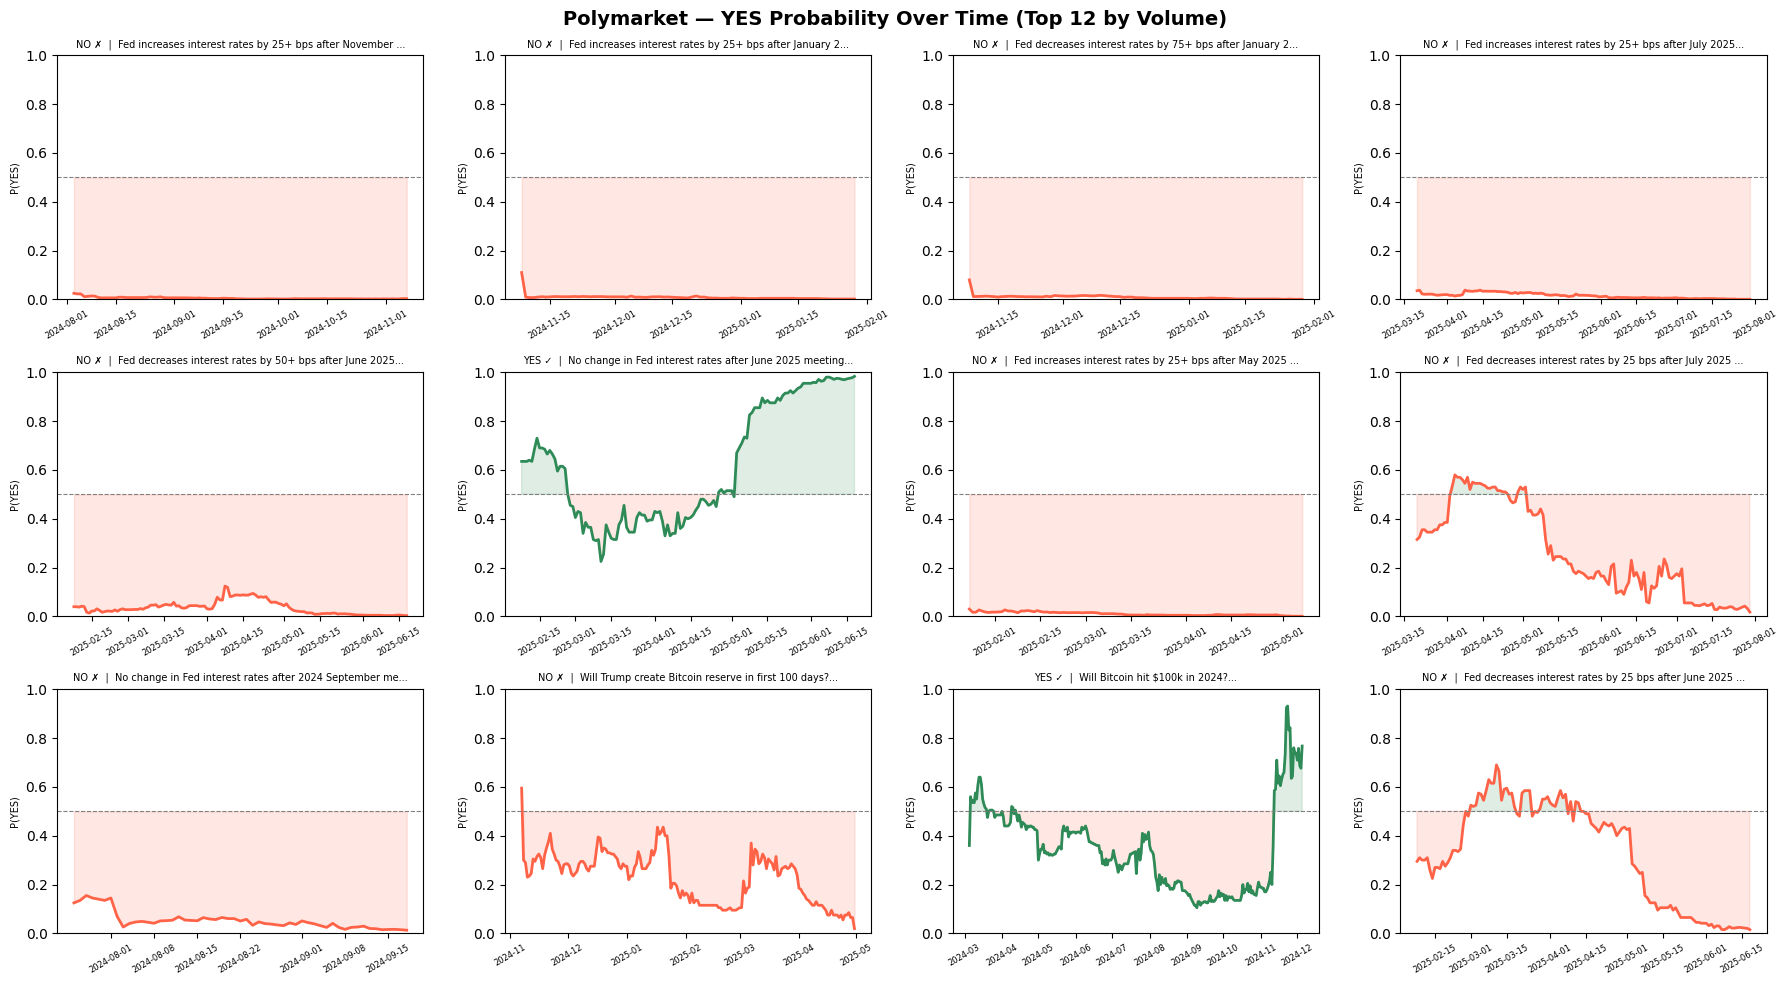

In [7]:
df = conn.execute("""
    SELECT
        m.id         AS market_id,
        m.question,
        m.resolved_yes,
        ph.ts::DATE  AS date,
        ph.price     AS yes_price
    FROM price_history ph
    JOIN market_outcomes mo ON mo.token_id = ph.token_id
    JOIN markets m ON m.id = mo.market_id
    WHERE mo.name IN ('Yes', 'Up')
      AND m.resolved = true
    ORDER BY m.volume_total DESC, ph.ts
""").df()

top_markets = df['market_id'].unique()[:12]
df_top = df[df['market_id'].isin(top_markets)]

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
fig.suptitle('Polymarket — YES Probability Over Time (Top 12 by Volume)', 
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, mid in enumerate(top_markets):
    sub = df_top[df_top['market_id'] == mid].sort_values('date')
    resolved_yes = sub['resolved_yes'].iloc[0]
    question = sub['question'].iloc[0][:55] + '...'
    color = 'seagreen' if resolved_yes else 'tomato'
    outcome = 'YES ✓' if resolved_yes else 'NO ✗'

    axes[i].plot(sub['date'], sub['yes_price'], color=color, lw=2)
    axes[i].axhline(0.5, color='gray', lw=0.8, linestyle='--')
    axes[i].fill_between(sub['date'], sub['yes_price'], 0.5,
                         where=sub['yes_price'] > 0.5, alpha=0.15, color='seagreen')
    axes[i].fill_between(sub['date'], sub['yes_price'], 0.5,
                         where=sub['yes_price'] < 0.5, alpha=0.15, color='tomato')
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'{outcome}  |  {question}', fontsize=7)
    axes[i].tick_params(axis='x', labelsize=6, rotation=30)
    axes[i].set_ylabel('P(YES)', fontsize=7)

plt.tight_layout()
plt.show()

## 2. Price convergence — do markets resolve cleanly?
Plot all markets aligned by days-to-close. Do YES markets converge to 1.0 and NO markets to 0.0?

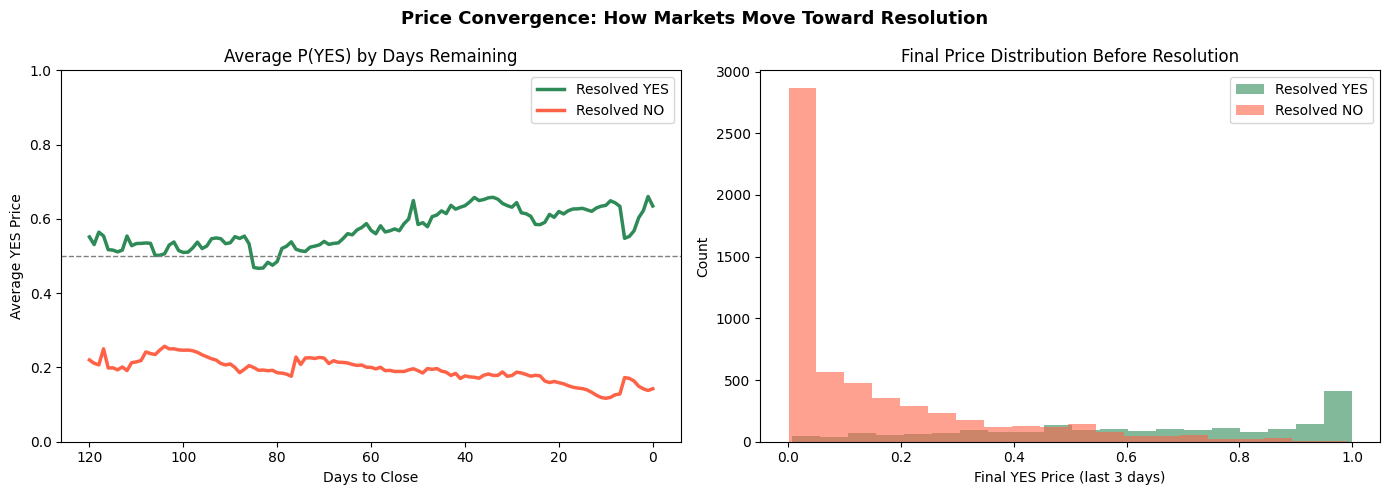

In [8]:
df_conv = conn.execute("""
    SELECT
        m.id           AS market_id,
        m.resolved_yes,
        ph.price       AS yes_price,
        DATEDIFF('day', ph.ts::DATE, m.end_date::DATE) AS days_to_close
    FROM price_history ph
    JOIN market_outcomes mo ON mo.token_id = ph.token_id
    JOIN markets m ON m.id = mo.market_id
    WHERE mo.name IN ('Yes', 'Up')
      AND m.resolved = true
      AND m.resolved_yes IS NOT NULL
      AND DATEDIFF('day', ph.ts::DATE, m.end_date::DATE) BETWEEN 0 AND 120
""").df()

# Average price by days_to_close and outcome
avg = df_conv.groupby(['days_to_close', 'resolved_yes'])['yes_price'].mean().reset_index()
yes_avg = avg[avg['resolved_yes'] == True].sort_values('days_to_close', ascending=False)
no_avg  = avg[avg['resolved_yes'] == False].sort_values('days_to_close', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Convergence: How Markets Move Toward Resolution', 
             fontsize=13, fontweight='bold')

# Left: avg convergence curves
ax1.plot(yes_avg['days_to_close'], yes_avg['yes_price'], 
         color='seagreen', lw=2.5, label='Resolved YES')
ax1.plot(no_avg['days_to_close'],  no_avg['yes_price'],  
         color='tomato',   lw=2.5, label='Resolved NO')
ax1.axhline(0.5, color='gray', lw=1, linestyle='--')
ax1.invert_xaxis()
ax1.set_xlabel('Days to Close')
ax1.set_ylabel('Average YES Price')
ax1.set_title('Average P(YES) by Days Remaining')
ax1.legend()
ax1.set_ylim(0, 1)

# Right: distribution of final prices (should be near 0 or 1)
final = df_conv[df_conv['days_to_close'] <= 3]
ax2.hist(final[final['resolved_yes'] == True]['yes_price'],  
         bins=20, alpha=0.6, color='seagreen', label='Resolved YES')
ax2.hist(final[final['resolved_yes'] == False]['yes_price'], 
         bins=20, alpha=0.6, color='tomato',   label='Resolved NO')
ax2.set_xlabel('Final YES Price (last 3 days)')
ax2.set_ylabel('Count')
ax2.set_title('Final Price Distribution Before Resolution')
ax2.legend()

plt.tight_layout()
plt.show()

## 3. Macro variable alongside market price
Plot USD/JPY vs a USD/JPY threshold market to see if the underlying asset drives the probability.

In [9]:
# Find a USD/JPY market with price history
fx_markets = conn.execute("""
    SELECT m.id, m.question, m.resolved_yes, COUNT(ph.ts) as rows
    FROM markets m
    JOIN market_outcomes mo ON mo.market_id = m.id AND mo.name IN ('Yes','Up')
    JOIN price_history ph ON ph.token_id = mo.token_id
    WHERE LOWER(m.question) LIKE '%usd%jpy%' 
       OR LOWER(m.question) LIKE '%yen%'
       OR LOWER(m.question) LIKE '%bitcoin%'
       OR LOWER(m.question) LIKE '%btc%'
    GROUP BY m.id, m.question, m.resolved_yes
    HAVING COUNT(ph.ts) >= 20
    ORDER BY rows DESC
    LIMIT 10
""").df()

print('Markets with price history:')
print(fx_markets[['question','resolved_yes','rows']].to_string(index=False))

Markets with price history:
                                                   question  resolved_yes  rows
                   Will a new country buy Bitcoin in 2024?          False   308
                            Will Bitcoin hit $100k in 2024?          True   276
       Will Trump create Bitcoin reserve in first 100 days?         False   175
                    US government Bitcoin reserves in 2024?         False   173
                          Will China unban Bitcoin in 2024?         False   170
Trump's sovereign wealth fund acquires Bitcoin before July?         False   148
            Will Trump Media invest in Bitcoin before July?         False   136
                      Will China unban Bitcoin by March 31?         False   120
                   Will Bitcoin reach $150,000 by March 31?         False   110
                   Will Bitcoin reach $200,000 by March 31?         False   110


Market: Will a new country buy Bitcoin in 2024? 
Resolved YES: False
Macro overlay: bitcoin


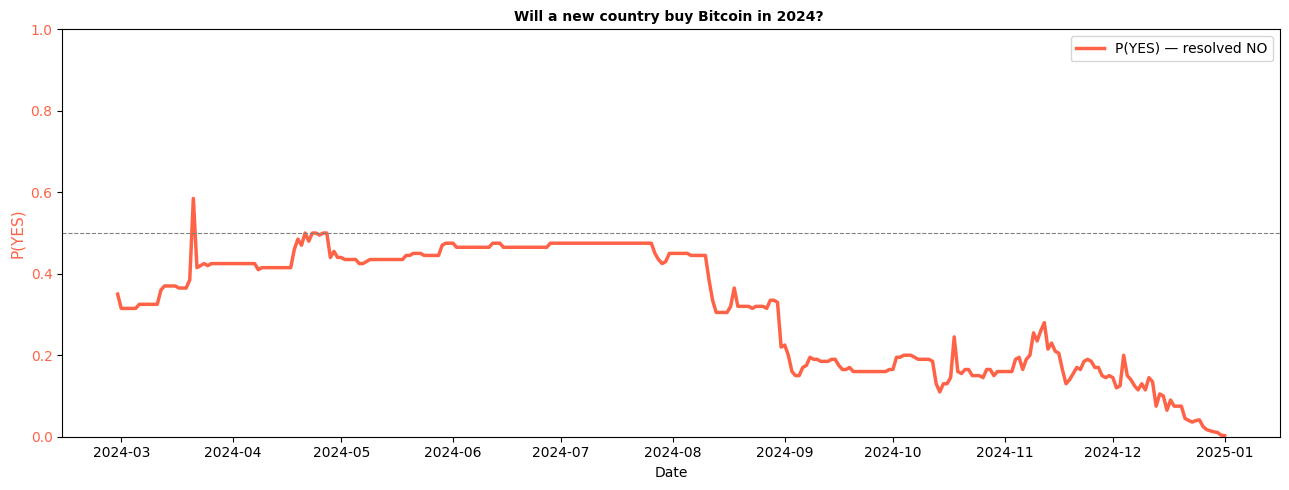

In [10]:
if len(fx_markets) == 0:
    print('No FX/BTC markets with enough price history — plotting top market instead')
    market_id = conn.execute("""
        SELECT m.id FROM markets m
        JOIN market_outcomes mo ON mo.market_id = m.id AND mo.name IN ('Yes','Up')
        JOIN price_history ph ON ph.token_id = mo.token_id
        GROUP BY m.id HAVING COUNT(*) >= 20
        ORDER BY COUNT(*) DESC LIMIT 1
    """).fetchone()[0]
    macro_ticker = 'vix'
else:
    market_id = fx_markets.iloc[0]['id']
    question  = fx_markets.iloc[0]['question'].lower()
    macro_ticker = 'usdjpy' if 'jpy' in question or 'yen' in question else 'bitcoin' if 'btc' in question or 'bitcoin' in question else 'vix'

# Fetch market price history
mkt = conn.execute(f"""
    SELECT ph.ts::DATE AS date, ph.price AS yes_price
    FROM price_history ph
    JOIN market_outcomes mo ON mo.token_id = ph.token_id
    WHERE mo.market_id = '{market_id}' AND mo.name IN ('Yes','Up')
    ORDER BY ph.ts
""").df()

# Fetch macro variable over same period
macro = conn.execute(f"""
    SELECT date, value
    FROM macro_data
    WHERE ticker = '{macro_ticker}'
      AND date BETWEEN '{mkt['date'].min()}' AND '{mkt['date'].max()}'
    ORDER BY date
""").df()

question_text = conn.execute(f"SELECT question, resolved_yes FROM markets WHERE id = '{market_id}'").fetchone()
print(f'Market: {question_text[0]}')
print(f'Resolved YES: {question_text[1]}')
print(f'Macro overlay: {macro_ticker}')

fig, ax1 = plt.subplots(figsize=(13, 5))
color1, color2 = ('seagreen' if question_text[1] else 'tomato'), 'steelblue'

ax1.plot(mkt['date'], mkt['yes_price'], color=color1, lw=2.5,
         label=f'P(YES) — resolved {"YES" if question_text[1] else "NO"}')
ax1.axhline(0.5, color='gray', lw=0.8, linestyle='--')
ax1.set_ylabel('P(YES)', color=color1, fontsize=11)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y', labelcolor=color1)

if not macro.empty:
    ax2 = ax1.twinx()
    ax2.plot(pd.to_datetime(macro['date']), macro['value'], 
             color=color2, lw=1.5, linestyle='--', alpha=0.8,
             label=macro_ticker.upper())
    ax2.set_ylabel(macro_ticker.upper(), color=color2, fontsize=11)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.legend(loc='upper left')

ax1.set_title(f'{question_text[0][:90]}', fontsize=10, fontweight='bold')
ax1.legend(loc='upper right')
ax1.set_xlabel('Date')
plt.tight_layout()
plt.show()

## 4. Fed rate decision markets — all on one chart
Shows the full landscape of Fed rate decision probabilities over time.

Fed markets with history: 100


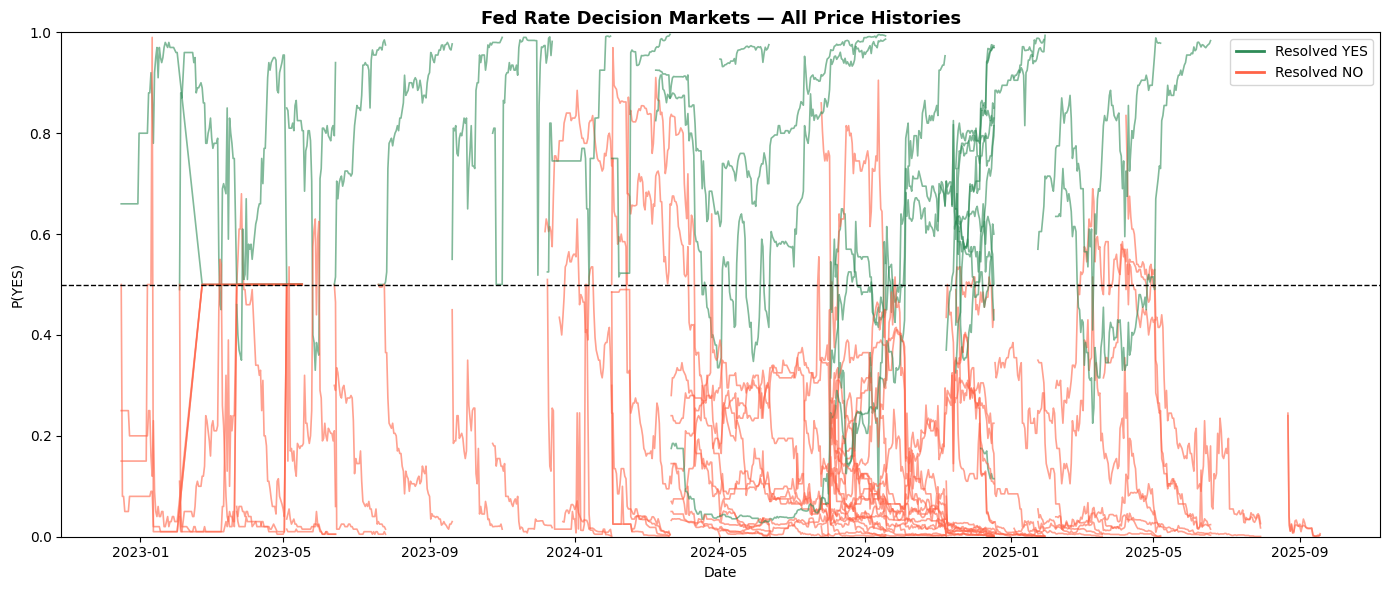

In [11]:
fed = conn.execute("""
    SELECT
        m.question,
        m.resolved_yes,
        ph.ts::DATE  AS date,
        ph.price     AS yes_price
    FROM price_history ph
    JOIN market_outcomes mo ON mo.token_id = ph.token_id
    JOIN markets m ON m.id = mo.market_id
    WHERE mo.name IN ('Yes','Up')
      AND m.resolved = true
      AND (LOWER(m.question) LIKE '%fed%rate%' OR LOWER(m.question) LIKE '%fomc%'
           OR LOWER(m.question) LIKE '%interest rate%bps%')
    ORDER BY m.question, ph.ts
""").df()

print(f'Fed markets with history: {fed["question"].nunique()}')

if fed['question'].nunique() > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    for q, grp in fed.groupby('question'):
        resolved = grp['resolved_yes'].iloc[0]
        color = 'seagreen' if resolved else 'tomato'
        ax.plot(grp['date'], grp['yes_price'], color=color, lw=1.2, alpha=0.6)

    ax.axhline(0.5, color='black', lw=1, linestyle='--', label='50%')
    from matplotlib.lines import Line2D
    legend = [
        Line2D([0],[0], color='seagreen', lw=2, label='Resolved YES'),
        Line2D([0],[0], color='tomato',   lw=2, label='Resolved NO'),
    ]
    ax.legend(handles=legend)
    ax.set_ylim(0, 1)
    ax.set_title('Fed Rate Decision Markets — All Price Histories', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('P(YES)')
    plt.tight_layout()
    plt.show()
else:
    print('No Fed markets with price history found — check keyword filter')